In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/facial-keypoints-detection/training.zip
/kaggle/input/competitions/facial-keypoints-detection/SampleSubmission.csv
/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv
/kaggle/input/competitions/facial-keypoints-detection/test.zip


In [6]:
pip install mlflow dagshub

Note: you may need to restart the kernel to use updated packages.


In [39]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from torchmetrics import MeanSquaredError
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import mlflow
import dagshub
import copy
from dataclasses import dataclass, asdict

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
dagshub.init('facial_keypoints_prediction','Neeharika-J',mlflow=True)
mlflow.set_tracking_uri('https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow')
mlflow.set_experiment(experiment_name='facial_keypoints_cnn_with_optuna')

Initialized MLflow to track repo "Neeharika-J/facial_keypoints_prediction"

Repository Neeharika-J/facial_keypoints_prediction initialized!

<Experiment: artifact_location='mlflow-artifacts:/7335da164d7442b6a8dd7e29c670ac59', creation_time=1784700624690, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1784700624690, lifecycle_stage='active', name='facial_keypoints_cnn_with_optuna', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [12]:
train = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/training.zip')
idlookuptable = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv')
samplesubmission = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/SampleSubmission.csv')
test = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/test.zip')


In [13]:
X = train['Image']
y = train.drop(columns=['Image'])

In [14]:
X.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7049 entries, 0 to 7048
Series name: Image
Non-Null Count  Dtype 
--------------  ----- 
7049 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [15]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          7039 non-null   float64
 1   left_eye_center_y          7039 non-null   float64
 2   right_eye_center_x         7036 non-null   float64
 3   right_eye_center_y         7036 non-null   float64
 4   left_eye_inner_corner_x    2271 non-null   float64
 5   left_eye_inner_corner_y    2271 non-null   float64
 6   left_eye_outer_corner_x    2267 non-null   float64
 7   left_eye_outer_corner_y    2267 non-null   float64
 8   right_eye_inner_corner_x   2268 non-null   float64
 9   right_eye_inner_corner_y   2268 non-null   float64
 10  right_eye_outer_corner_x   2268 non-null   float64
 11  right_eye_outer_corner_y   2268 non-null   float64
 12  left_eyebrow_inner_end_x   2270 non-null   float64
 13  left_eyebrow_inner_end_y   2270 non-null   float

In [16]:
print(f'X type: {type(X[0])}')

X type: <class 'str'>


In [17]:
# Convert to numpy array 
X = [np.fromstring(img,dtype=np.float32,sep=' ')/ 255.0 for img in X]

In [18]:
print(f'X type: {type(X[0])}')

X type: <class 'numpy.ndarray'>


#### Handling Null Values using MASK

In [19]:
print(f'y type: {type(y)}')

y type: <class 'pandas.core.frame.DataFrame'>


In [20]:
# converting y to numpy array:
y = y.to_numpy(dtype=np.float32)
mask = ~np.isnan(y)
y = np.nan_to_num(y, nan=0.0)

In [21]:
print(f'y type: {type(y)}')

y type: <class 'numpy.ndarray'>


In [22]:
print(f'X shape: {len(X)}')
print(f'y shape: {len(y)}')

X shape: 7049
y shape: 7049


#### Train-test split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [24]:
print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")
print(f"X_test: {len(X_test)}")
print(f"y_test: {len(y_test)}")
print(f"X_train[0]: {X_train[0]}")

X_train: 5639
y_train: 5639
X_test: 1410
y_test: 1410
X_train[0]: [0.00392157 0.         0.00392157 ... 0.         0.         0.        ]


In [25]:
X_train[0]

array([0.00392157, 0.        , 0.00392157, ..., 0.        , 0.        ,
       0.        ], dtype=float32)

In [26]:
def show_image(image, keypoints=None):
    """
    image: numpy array of shape (96,96)
    keypoints: numpy array of shape (30,) or None
    """

    plt.imshow(image.reshape(96,96), cmap="gray")

    if keypoints is not None:
        plt.scatter(keypoints[0::2], keypoints[1::2], c="red", s=20)

    plt.axis("off")
    plt.show()

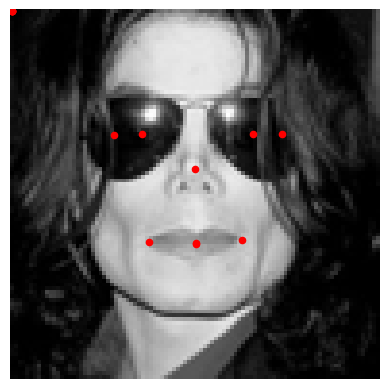

In [27]:
show_image(X_train[0], y_train[0])

In [28]:
train_transform = A.Compose([
    A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.8),
    A.Affine(p=0.2),
#     A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, brightness_by_max=False, p=0.2),
    A.OneOf([
#             A.GaussNoise(p=0.8),
#             A.RandomGamma(p=0.8),
            A.Blur(blur_limit=3, p=0.8),
            A.PixelDropout(p=0.8)
        ], p=1.0),     
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.2, border_mode=cv2.BORDER_CONSTANT),
    ],
    keypoint_params = A.KeypointParams(format = 'xy', remove_invisible=False)
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [29]:
class FaceDataset(Dataset):

    def __init__(self, X, y, mask, transform=None):
        self.X = X
        self.y = y
        self.mask = mask
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        X = self.X[idx].reshape(96, 96)
        y = self.y[idx].reshape(-1, 2)
    
        if self.transform:
            transformed = self.transform(
                image=X,
                keypoints=y
            )
    
            X = transformed["image"]
            y = np.array(transformed["keypoints"])
    
        # Flatten keypoints back to (30,)
        y = y.reshape(-1)
    
        # Convert to tensors
        X = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
    
        # Repeat grayscale channel -> (3, 96, 96)
        X = X.repeat(3, 1, 1)
    
        y = torch.tensor(y, dtype=torch.float32)
        mask = torch.tensor(self.mask[idx], dtype=torch.bool)

        return X, y, mask

In [30]:
print(type(X),type(y))

<class 'list'> <class 'numpy.ndarray'>


In [31]:
train_dataset = FaceDataset(
    X,y,mask,transform=train_transform
)

val_dataset = FaceDataset(
    X,y,mask,transform=None
)

In [32]:
image, keypoints, mask = train_dataset[0]
print(image.shape,keypoints.shape,mask.shape)

torch.Size([3, 96, 96]) torch.Size([30]) torch.Size([30])


#### Print tensor image

In [33]:
import matplotlib.pyplot as plt

def show_image(image, keypoints=None):
    """
    image: torch.Tensor of shape (3,96,96), (1,96,96), or (96,96)
    keypoints: torch.Tensor of shape (30,) or None
    """

    image = image.cpu()

    if image.ndim == 3:
        if image.shape[0] == 3:
            # Display first channel (all three are identical)
            image = image[0]
        elif image.shape[0] == 1:
            image = image.squeeze(0)

    plt.imshow(image.numpy(), cmap="gray")

    if keypoints is not None:
        keypoints = keypoints.cpu().numpy()
        plt.scatter(
            keypoints[0::2],
            keypoints[1::2],
            c="red",
            s=20
        )

    plt.axis("off")
    plt.show()

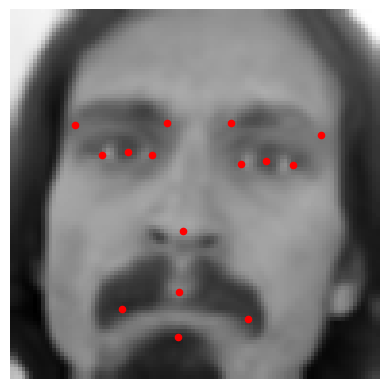

In [34]:
image, keypoints, mask = train_dataset[0]
show_image(image, keypoints)

In [35]:
def get_dataloaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2, #for increasing training speed
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2, 
    )
    return train_loader,val_loader

In [36]:

criterion = nn.MSELoss(reduction='none').to(device)
rmse = MeanSquaredError(squared=False).to(device)

In [37]:
import optuna
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import resnet18, ResNet18_Weights

# 1. System Metrics Logging (Configured for performance)
mlflow.enable_system_metrics_logging()
mlflow.set_system_metrics_sampling_interval(30)  # Polling every 30s keeps it fast

def objective(trial):
    # --- 1. SAMPLE HYPERPARAMETERS FOR THIS TRIAL ---
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)      
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    epochs = 30  # Keep epochs fixed and let Optuna prune bad runs
    
    # --- 2. RE-INITIALIZE DATA, MODEL & OPTIMIZER ---
    train_loader, val_loader = get_dataloaders(batch_size=batch_size)
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 30)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(
        optimizer=optimizer, 
        mode="min", 
        factor=0.5,
        patience=5,
        min_lr=1e-15
    )

    # --- 3. START MLFLOW NESTED RUN FOR THIS TRIAL ---
    with mlflow.start_run(nested=True):
        mlflow.log_params({
            "BATCH_SIZE": batch_size,
            "N_EPOCHS": epochs,
            "LEARNING_RATE": lr,
            "TRIAL_NUMBER": trial.number
        })

        best_val_loss = float("inf")

        for epoch in range(epochs):
            # --- TRAINING PHASE ---
            model.train()
            running_train_loss = 0.0
            current_lr = optimizer.param_groups[0]['lr']

            for images, targets, mask in train_loader:
                images, targets, mask = images.to(device), targets.to(device), mask.to(device)
                
                optimizer.zero_grad()
                predictions = model(images)
                loss = criterion(predictions, targets)
                
                masked_loss = loss[mask]
                if masked_loss.numel() > 0:
                    loss_val = masked_loss.mean()
                    loss_val.backward()
                    optimizer.step()
                    running_train_loss += loss_val.item()

            epoch_train_loss = running_train_loss / len(train_loader)

            # --- VALIDATION PHASE ---
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for val_images, val_targets, val_mask in val_loader:
                    val_images = val_images.to(device)
                    val_targets = val_targets.to(device)
                    val_mask = val_mask.to(device)

                    val_preds = model(val_images)
                    v_loss = criterion(val_preds, val_targets)[val_mask]
                    if v_loss.numel() > 0:
                        running_val_loss += v_loss.mean().item()

            epoch_val_loss = running_val_loss / len(val_loader)
            scheduler.step(epoch_val_loss)

            # Log metrics to MLflow
            mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
            mlflow.log_metric("learning_rate", current_lr, step=epoch)

            # Track lowest val loss in THIS trial
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss

            # --- 4. OPTUNA PRUNING ---
            trial.report(epoch_val_loss, step=epoch)
            if trial.should_prune():
                mlflow.set_tag("status", "PRUNED")
                raise optuna.exceptions.TrialPruned()

        # --- 5. SAVE MODEL ONLY IF NEW GLOBAL BEST SCORE ---
        # Checks if this trial beat all previous trials across the whole study
        is_first_trial = trial.number == 0
        is_new_best = not is_first_trial and best_val_loss < trial.study.best_value
        if is_first_trial or is_new_best:
            # 1. Create a dummy input batch matching your image shape
            # Example: batch of 1, 3 color channels, 224x224 image size
            dummy_input = torch.randn(1, 3, 224, 224, device=device)
            model_to_log = copy.deepcopy(model).cpu()
            model_to_log.eval()
            # 2. Pass input_example into log_model
            mlflow.pytorch.log_model(
                pytorch_model=model_to_log,
                name="FKCNNmodel",
                registered_model_name="MyFKCNNModel",
                serialization_format="pickle", 
            )
            mlflow.set_tag("checkpoint", "NEW_BEST_MODEL")
            print(f"--> Saved new best pickle model artifact! (Val Loss: {best_val_loss:.4f})")

        # --- 6. RETURN SCORE TO OPTUNA ---
        return best_val_loss

In [40]:
if __name__ == "__main__":
    # Parent MLflow run to group all trial runs together
    with mlflow.start_run(run_name="Optuna_Hyperparameter_Search"):
        study = optuna.create_study(
            direction="minimize",
            pruner=optuna.pruners.MedianPruner(n_warmup_steps=5) # Don't prune before 5 epochs
        )
        
        study.optimize(objective, n_trials=10)

        print("\n--- OPTUNA OPTIMIZATION COMPLETE ---")
        print("Best Trial Score (Val Loss):", study.best_value)
        print("Best Parameters Found:")
        for key, val in study.best_params.items():
            print(f"  {key}: {val}")

2026/07/22 17:23:54 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
[I 2026-07-22 17:23:54,400] A new study created in memory with name: no-name-f4fc9fc5-8825-4c7a-bc87-231c3c128fd9
2026/07/22 17:23:54 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/22 17:28:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/22 17:28:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip

--> Saved new best pickle model artifact! (Val Loss: 2.4187)
🏃 View run amusing-shoat-391 at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4/runs/7f4d38d5992d46dba363fda3d12a9c86
🧪 View experiment at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4


2026/07/22 17:28:37 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/22 17:28:37 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-07-22 17:28:37,281] Trial 0 finished with value: 2.418732848253336 and parameters: {'lr': 0.0005885665731064007, 'batch_size': 64}. Best is trial 0 with value: 2.418732848253336.
2026/07/22 17:28:37 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/22 17:33:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/22 17:33:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.

--> Saved new best pickle model artifact! (Val Loss: 2.2097)
🏃 View run serious-snake-462 at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4/runs/e9f78b62f08246f5916fa0a3a4420786
🧪 View experiment at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4


2026/07/22 17:34:10 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-07-22 17:34:10,378] Trial 1 finished with value: 2.209679969295657 and parameters: {'lr': 0.0009623056660714619, 'batch_size': 32}. Best is trial 1 with value: 2.209679969295657.
2026/07/22 17:34:10 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/22 17:38:20 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/22 17:38:20 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-07-22 17:38:20,943] Trial 2 finished with value: 2.672984539925515 and parameters: {'lr': 0.0005508939917026129, 'batch_size': 64}. Best is trial 1 with value: 2.209679969295657.


...

2026/07/22 18:00:33 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-07-22 18:00:33,324] Trial 8 pruned. 
2026/07/22 18:00:33 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/22 18:01:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run bold-pig-857 at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4/runs/2e7cf14f4a174e96b8b55b86f6e5370f
🧪 View experiment at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4


2026/07/22 18:01:23 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
[I 2026-07-22 18:01:23,666] Trial 9 pruned. 



--- OPTUNA OPTIMIZATION COMPLETE ---
Best Trial Score (Val Loss): 2.1477815554692197
Best Parameters Found:
  lr: 0.0002953303124801529
  batch_size: 32
🏃 View run Optuna_Hyperparameter_Search at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4/runs/1a2801a9220149b0920697ffc50c81ec
🧪 View experiment at: https://dagshub.com/Neeharika-J/facial_keypoints_prediction.mlflow/#/experiments/4


2026/07/22 18:01:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/22 18:01:24 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [ ]:
import optuna.visualization as vis

# 1. Plot optimization history (how loss improved over trials)
fig_history = vis.plot_optimization_history(study)
fig_history.show()

# 2. Parallel Coordinate Plot (shows relationships between parameters and loss)
fig_parallel = vis.plot_parallel_coordinate(study)
fig_parallel.show()

# 3. Parameter Importances (shows WHICH parameter mattered the most!)
fig_importance = vis.plot_param_importances(study)
fig_importance.show()